# char_10 — the three Ethiopian seasons, spectrum by spectrum

## Purpose

`char_09` split the Addis spectra into **dry** and **non-dry** halves and showed the
two mean curves diverging exactly where charcoal is matched. But "non-dry" pools two
different rainy seasons — **Belg** (short rains, Mar–May) and **Kiremt** (long rains,
Jun–Sep) — and no notebook has yet shown the spectra at full seasonal resolution.

This notebook is purely descriptive, and deliberately contains no charcoal at all:

1. **The raw spectra, as measured — and the baselined shapes that make them
   readable** — panel A: full instrument range, raw absorbance, no corrections, in the
   style of Weakley, Takahama & Dillner (2018, *Aerosol Sci. Technol.* 52:9,
   Figure 5a), per-season mean solid with 5th/95th percentiles dashed; panel B: the
   same filters AIRSpec-baselined and area-normalized, where the seasonal comparison
   becomes possible.
2. **Each season as its own curve on one graph** — the three seasonal means with their
   10–90 % spread bands, the direct analogue of `char_09`'s dry/non-dry overlay.
3. **All of them on one graph** — every individual filter spectrum, coloured by season,
   with the three seasonal means and the pooled all-filter mean on top.
4. **Season by season in detail** — one panel per season so each population's internal
   spread is readable on its own.

Every figure and number from section 1's second panel onward lives in one
representation: **AIRSpec-baselined + area-normalized** (`clip(·,0)/∫`). The folder's
crop → detrend → SNV chain exists to make Addis comparable to lab charcoal spectra
across instruments; this notebook compares Addis only with itself, so that chain is
not needed and the more readable absorbance-like shapes are used throughout.

It also answers the question `char_07`/`char_09` skipped when they pooled the rainy
seasons: **do Belg and Kiremt actually look the same**, i.e. was treating them as one
"non-dry" population justified?

## Takeaways

See the end of the notebook.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path("scripts").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from IPython.display import display
from scipy import stats

from charcoal_spectra import band_area, BANDS
from etad_spectra import load_etad

PLOT_DIR = Path("output/plots/char10")
TABLE_DIR = Path("output/tables/char10")
for d in (PLOT_DIR, TABLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#7a7972", "axes.labelcolor": "#0b0b0b",
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "xtick.color": "#52514e", "ytick.color": "#52514e",
    "font.size": 10, "axes.titlesize": 11, "legend.frameon": False,
    "figure.dpi": 110,
})

INK, INK2, MUTED = "#0b0b0b", "#52514e", "#a3a29b"
ADDIS_COLOR = "#4a3aa7"

SEASON_COLORS = {
    "Dry Season": "#E67E22",
    "Belg Rainy Season": "#27AE60",
    "Kiremt Rainy Season": "#3498DB",
}
SEASON_MAP = {
    "Dry (Oct-Feb)": "Dry Season",
    "Belg (Mar-May)": "Belg Rainy Season",
    "Kiremt (Jun-Sep)": "Kiremt Rainy Season",
}
SEASON_ORDER = ["Dry Season", "Belg Rainy Season", "Kiremt Rainy Season"]
SHORT = {"Dry Season": "Dry (Oct–Feb)", "Belg Rainy Season": "Belg (Mar–May)",
         "Kiremt Rainy Season": "Kiremt (Jun–Sep)"}

ADDIS_PREP = ("Addis (ETAD): AIRSpec-baselined (APRLssb segmented spline, df1=6) "
              "→ clipped to ≥0 → unit positive area")


def stamp(fig, text=ADDIS_PREP):
    fig.text(0.5, -0.015, text, ha="center", va="top", fontsize=8, color=INK2)

## Load

AIRSpec-baselined ETAD spectra (available 1425–3998 cm⁻¹), then **area-normalized**
per spectrum — negatives clipped, unit positive area, the July07
`spectra_normalized_shapes` convention — so shape is comparable across deposit
loadings. No detrend, no SNV: those belong to the cross-source charcoal chain, which
this notebook does not use.

In [2]:
etad_meta, X_etad_base, wn_etad_b = load_etad(baselined=True)
etad_meta = etad_meta.copy()
etad_meta["season_label"] = etad_meta["season"].map(SEASON_MAP)

wn_b_asc = np.sort(wn_etad_b)


def area_norm(X):
    # July07 convention: clip negatives, unit positive area per spectrum.
    pos = np.clip(X, 0, None)
    a = np.trapezoid(pos[:, np.argsort(wn_etad_b)], wn_b_asc, axis=1)[:, None]
    a[a == 0] = np.nan
    return pos / np.abs(a)


X_shape = area_norm(X_etad_base)

season = etad_meta["season_label"].to_numpy()
masks = {s: season == s for s in SEASON_ORDER}

counts = pd.Series({SHORT[s]: int(m.sum()) for s, m in masks.items()},
                   name="n filters")
counts["all seasons"] = len(etad_meta)
display(counts.to_frame())
counts.to_frame().to_csv(TABLE_DIR / "season_counts.csv")

season_mean = {s: np.nanmean(X_shape[m], axis=0) for s, m in masks.items()}
pooled_mean = np.nanmean(X_shape, axis=0)

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08


,n filters
Dry (Oct–Feb),105
Belg (Mar–May),61
Kiremt (Jun–Sep),73
all seasons,239


## 1. The raw spectra — and the step that makes them readable

The **first figure** shows the data before anything the rest of this folder does to
it: the full instrument range (500–3998 cm⁻¹), raw absorbance units, no corrections —
after Weakley, Takahama & Dillner (2018), Figure 5a, with their two networks replaced
by the three seasons and their percentile dashes drawn as shaded 5–95 % bands. On this
view the seasons differ mostly in the height of the scattering ramp, and the actual
aerosol bands are invisible against it — nothing chemical is readable, and no
similarity between seasons can be seen. That is the README's argument for the
baseline correction, made visible. Annotations locate the **PTFE C–F doublet** at
1150/1210 cm⁻¹ (the filter substrate, and the reason nothing below ~1425 cm⁻¹ is
usable) and the **1430–3500 cm⁻¹ comparison window** the rest of the folder works in.

The **second figure** is the intermediate step between that raw view and every other
figure in this folder: the same filters **AIRSpec-baselined** (which removes the ramp
but only exists above 1425 cm⁻¹), then **area-normalized** so shape is comparable
across loadings — the same convention as the July07 `spectra_normalized_shapes`
figure (`clip(·,0)/∫`, before any detrend or SNV). Here the band structure appears
and the three seasons can actually be compared: the rainy pair nearly coincide, and
the dry season departs at 3040–3070 and the 3220 hump.

Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08


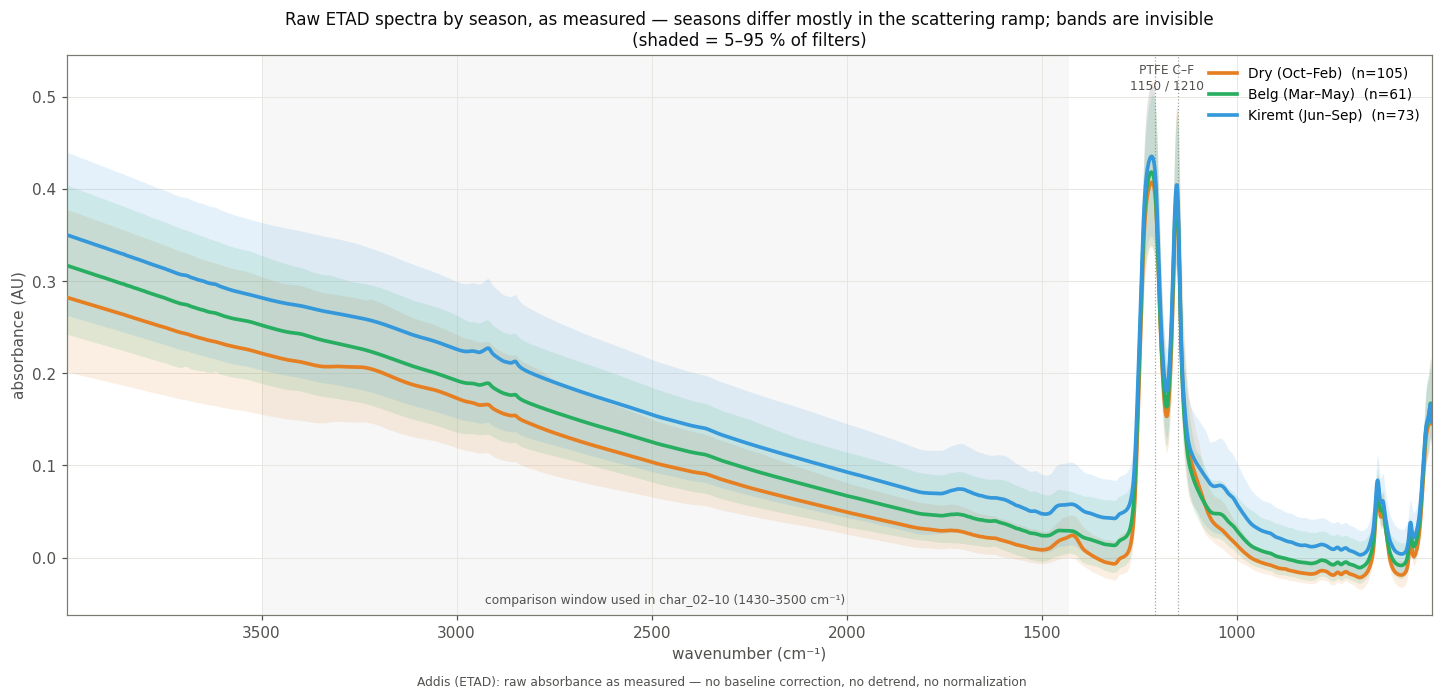

In [3]:
raw_meta, X_raw, wn_raw = load_etad(baselined=False)
raw_meta = raw_meta.copy()
raw_meta["season_label"] = raw_meta["season"].map(SEASON_MAP)

fig, ax = plt.subplots(figsize=(13, 6), constrained_layout=True)

ax.axvspan(1430, 3500, color=MUTED, alpha=0.08, lw=0, zorder=0)
for wn0 in (1150, 1210):
    ax.axvline(wn0, color=MUTED, lw=0.8, ls=":", zorder=1)

for s in SEASON_ORDER:
    m = (raw_meta["season_label"] == s).to_numpy()
    color = SEASON_COLORS[s]
    q5, q95 = np.percentile(X_raw[m], [5, 95], axis=0)
    ax.fill_between(wn_raw, q5, q95, color=color, alpha=0.13, lw=0, zorder=2)
    ax.plot(wn_raw, X_raw[m].mean(0), color=color, lw=2.4, zorder=4,
            label=f"{SHORT[s]}  (n={m.sum()})")

ymin, ymax = ax.get_ylim()
ax.annotate("PTFE C–F\n1150 / 1210", xy=(1180, ymax), xytext=(0, -6),
            textcoords="offset points", ha="center", va="top",
            fontsize=8, color=INK2)
ax.annotate("comparison window used in char_02–10 (1430–3500 cm⁻¹)",
            xy=((1430 + 3500) / 2, ymin), xytext=(0, 5),
            textcoords="offset points", ha="center", va="bottom",
            fontsize=8, color=INK2)
ax.set_xlim(wn_raw.max(), wn_raw.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("absorbance (AU)", color=INK2)
ax.set_title("Raw ETAD spectra by season, as measured — seasons differ mostly in the "
             "scattering ramp; bands are invisible\n(shaded = 5–95 % of filters)",
             color=INK)
ax.legend(fontsize=9, loc="upper right")
stamp(fig, "Addis (ETAD): raw absorbance as measured — no baseline correction, "
           "no detrend, no normalization")
fig.savefig(PLOT_DIR / "00a_raw_spectra.png", dpi=160, bbox_inches="tight")
plt.show()

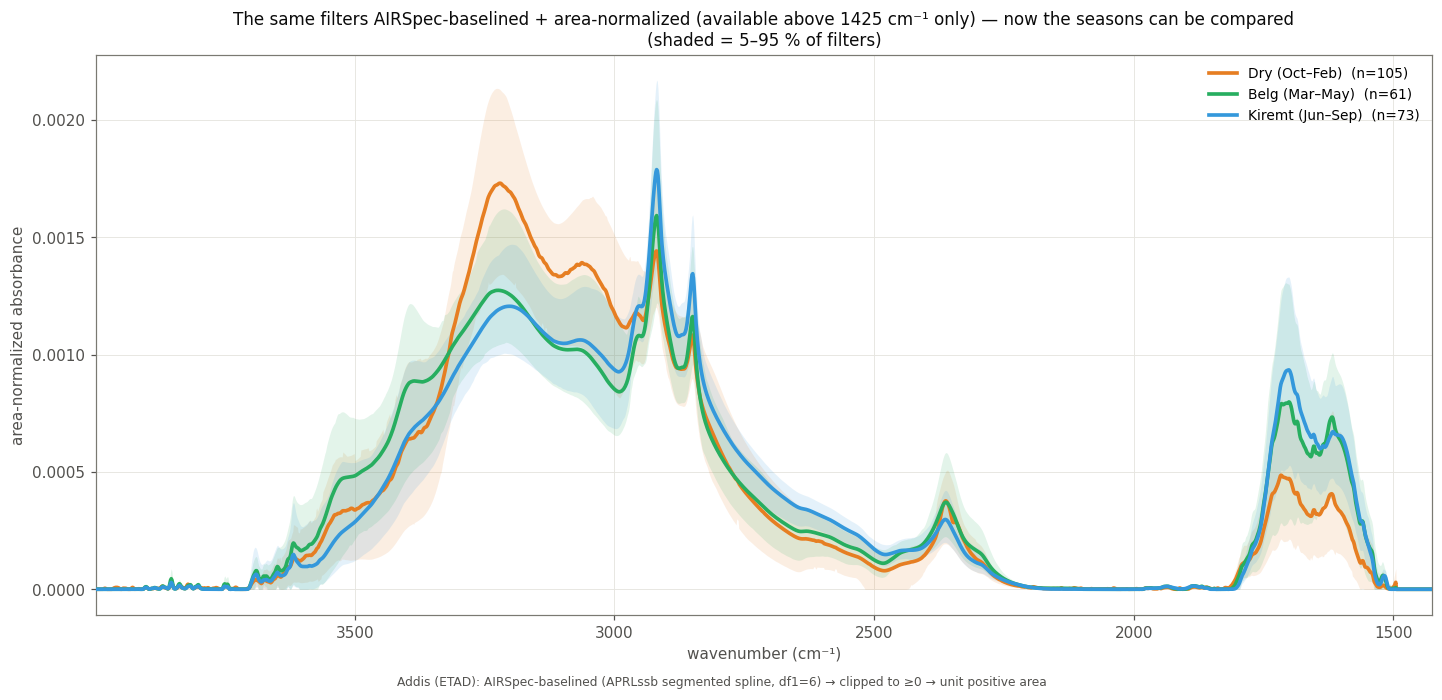

In [4]:
fig, ax = plt.subplots(figsize=(13, 6), constrained_layout=True)

for s in SEASON_ORDER:
    m = masks[s]
    color = SEASON_COLORS[s]
    q5, q95 = np.nanpercentile(X_shape[m], [5, 95], axis=0)
    ax.fill_between(wn_etad_b, q5, q95, color=color, alpha=0.13, lw=0, zorder=2)
    ax.plot(wn_etad_b, season_mean[s], color=color, lw=2.4,
            zorder=4, label=f"{SHORT[s]}  (n={m.sum()})")

ax.set_xlim(wn_b_asc.max(), wn_b_asc.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("area-normalized absorbance", color=INK2)
ax.set_title("The same filters AIRSpec-baselined + area-normalized (available above "
             "1425 cm⁻¹ only) — now the seasons can be compared\n"
             "(shaded = 5–95 % of filters)", color=INK)
ax.legend(fontsize=9, loc="upper right")
stamp(fig)
fig.savefig(PLOT_DIR / "00b_baselined_shapes.png", dpi=160, bbox_inches="tight")
plt.show()

## 2. The three seasons, each on its own curve

The direct analogue of `char_09`'s dry/non-dry overlay, in the area-normalized
representation: mean spectrum plus a 10–90 % band per season. The three season
colours are the canonical ones used throughout the repo (AGENTS.md); every curve is
also directly labelled, since the Belg/Dry pair sits in the CVD floor band.

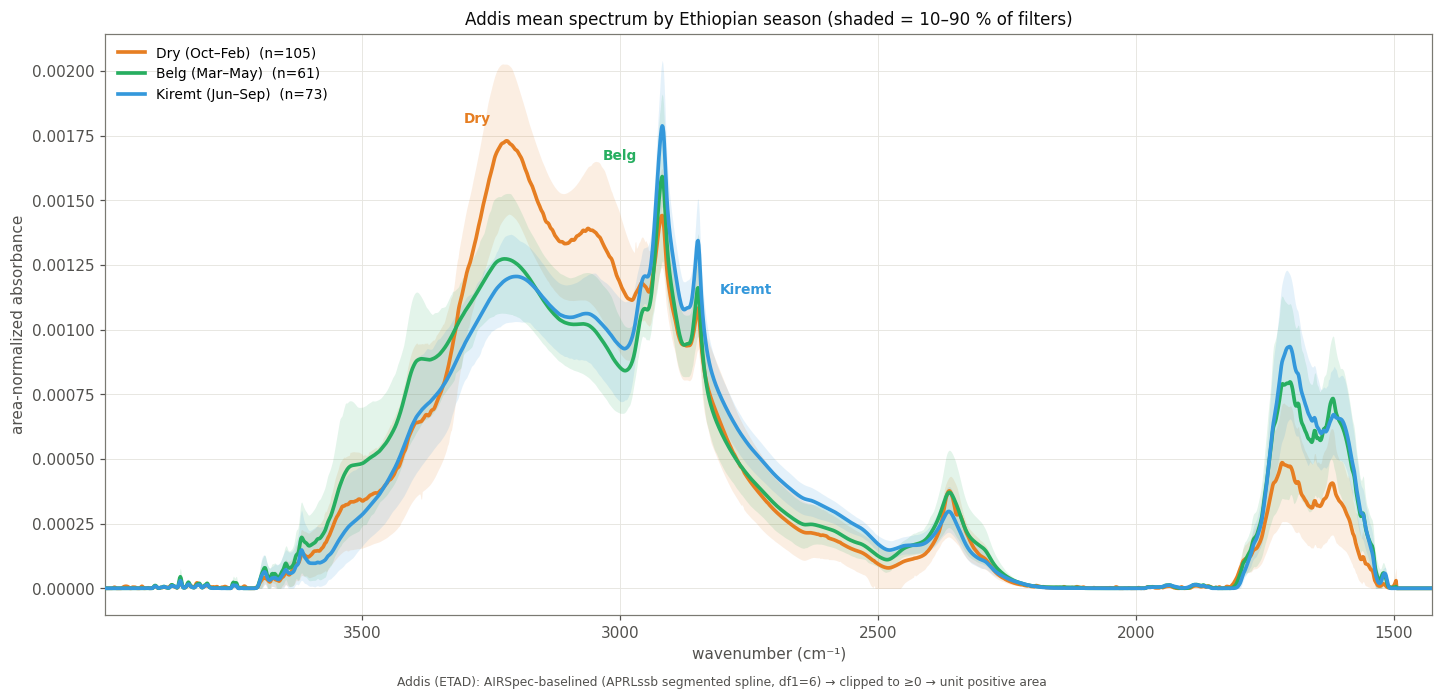

In [5]:
fig, ax = plt.subplots(figsize=(13, 6), constrained_layout=True)

for s in SEASON_ORDER:
    m, color = masks[s], SEASON_COLORS[s]
    q1, q3 = np.nanpercentile(X_shape[m], [10, 90], axis=0)
    ax.fill_between(wn_etad_b, q1, q3, color=color, alpha=0.13, lw=0, zorder=2)
    ax.plot(wn_etad_b, season_mean[s], color=color, lw=2.4, zorder=4,
            label=f"{SHORT[s]}  (n={m.sum()})")

# Direct labels, each at a wavenumber where that curve is separated from the others.
for s, wn0, dx, dy, va in [("Dry Season", 3220, -10, 10, "bottom"),
                           ("Belg Rainy Season", 2920, -16, 10, "bottom"),
                           ("Kiremt Rainy Season", 2854, 16, -12, "top")]:
    i = np.argmin(np.abs(wn_etad_b - wn0))
    ax.annotate(SHORT[s].split(" (")[0], (wn_etad_b[i], season_mean[s][i]),
                xytext=(dx, dy), textcoords="offset points",
                ha="right" if dx < 0 else "left", va=va, fontsize=9,
                color=SEASON_COLORS[s], fontweight="bold", zorder=6)

ax.set_xlim(wn_b_asc.max(), wn_b_asc.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("area-normalized absorbance", color=INK2)
ax.set_title("Addis mean spectrum by Ethiopian season (shaded = 10–90 % of filters)",
             color=INK)
ax.legend(fontsize=9, loc="upper left")
stamp(fig)
fig.savefig(PLOT_DIR / "01_seasonal_means.png", dpi=160, bbox_inches="tight")
plt.show()

## 3. All of them on one graph

Every individual filter spectrum, coloured by season, with the three seasonal means
and the pooled all-filter mean drawn on top (white-stroked so they stay readable over
the spaghetti).

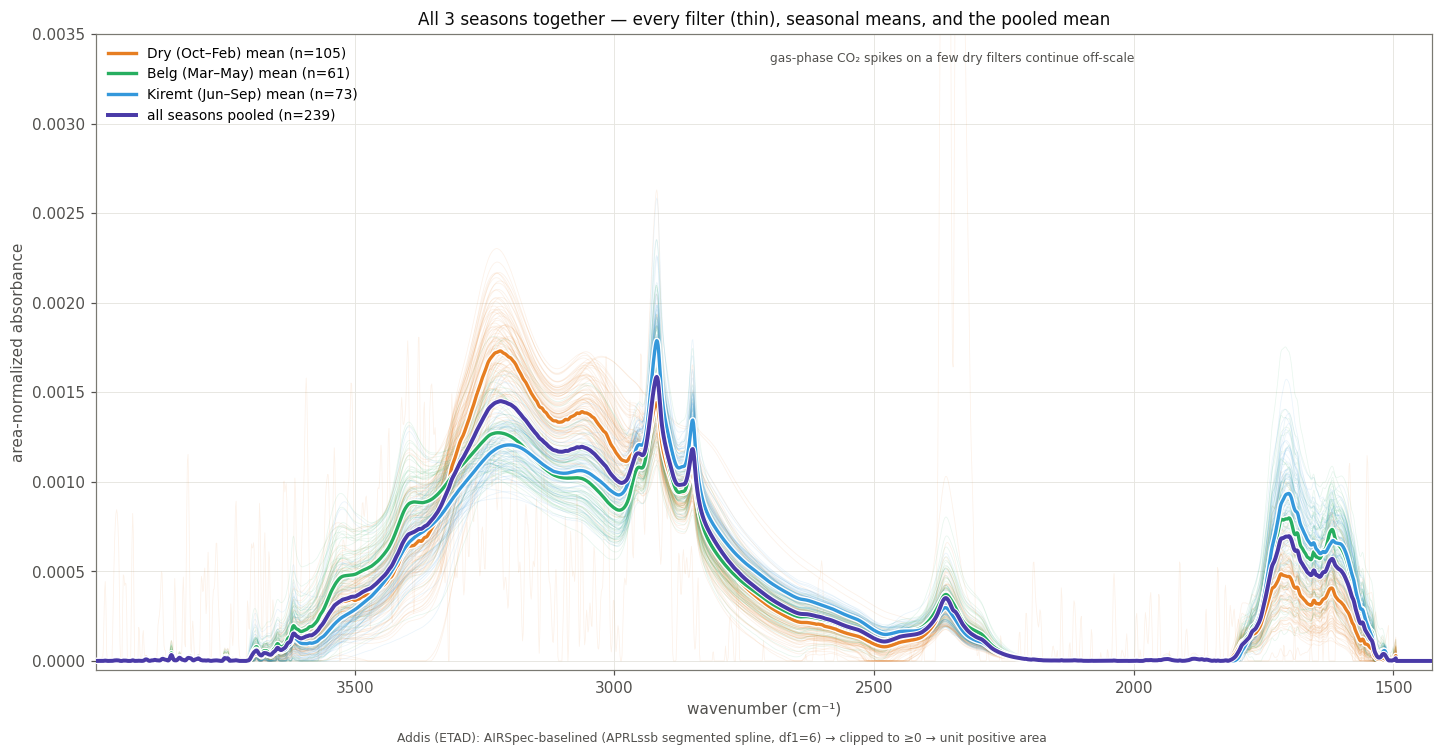

In [6]:
fig, ax = plt.subplots(figsize=(13, 6.5), constrained_layout=True)

for s in SEASON_ORDER:
    for row in X_shape[masks[s]]:
        ax.plot(wn_etad_b, row, color=SEASON_COLORS[s], lw=0.5, alpha=0.10, zorder=1)

outline = [pe.withStroke(linewidth=4, foreground="white")]
for s in SEASON_ORDER:
    ax.plot(wn_etad_b, season_mean[s], color=SEASON_COLORS[s], lw=2.2, zorder=4,
            path_effects=outline, label=f"{SHORT[s]} mean (n={masks[s].sum()})")
ax.plot(wn_etad_b, pooled_mean, color=ADDIS_COLOR, lw=2.6, zorder=5,
        path_effects=outline, label=f"all seasons pooled (n={len(etad_meta)})")

# A few dry-season filters carry gas-phase CO2 spikes near 2350 that would otherwise
# set the axis and squash every mean into the bottom quarter of the plot.
ax.set_ylim(-0.00005, 0.0035)
ax.annotate("gas-phase CO₂ spikes on a few dry filters continue off-scale",
            xy=(2350, 0.0034), ha="center", va="top", fontsize=8, color=INK2)
ax.set_xlim(wn_b_asc.max(), wn_b_asc.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("area-normalized absorbance", color=INK2)
ax.set_title("All 3 seasons together — every filter (thin), seasonal means, "
             "and the pooled mean", color=INK)
ax.legend(fontsize=9, loc="upper left")
stamp(fig)
fig.savefig(PLOT_DIR / "02_all_filters_and_means.png", dpi=160, bbox_inches="tight")
plt.show()

## 4. Season by season, in detail

One panel per season: that season's individual filters with its mean on top, and the
pooled all-season mean repeated in violet in each panel as a fixed reference, so the
panels can be compared against something common.

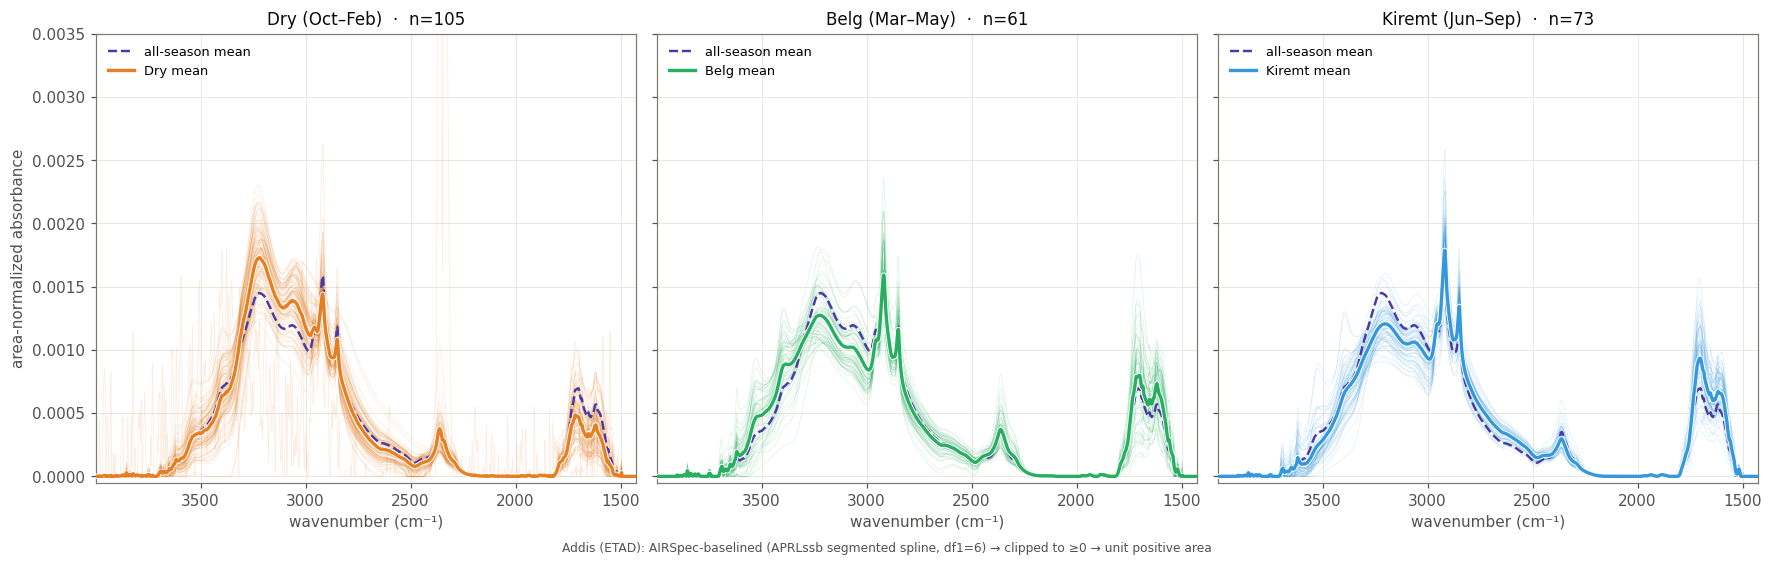

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True,
                         constrained_layout=True)
for ax, s in zip(axes, SEASON_ORDER):
    m, color = masks[s], SEASON_COLORS[s]
    for row in X_shape[m]:
        ax.plot(wn_etad_b, row, color=color, lw=0.5, alpha=0.14, zorder=1)
    ax.plot(wn_etad_b, pooled_mean, color=ADDIS_COLOR, lw=1.6, ls="--", zorder=3,
            label="all-season mean")
    ax.plot(wn_etad_b, season_mean[s], color=color, lw=2.2, zorder=4,
            path_effects=[pe.withStroke(linewidth=3.5, foreground="white")],
            label=f"{SHORT[s].split(' (')[0]} mean")
    ax.set_xlim(wn_b_asc.max(), wn_b_asc.min())
    ax.set_title(f"{SHORT[s]}  ·  n={m.sum()}", color=INK)
    ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
    ax.legend(fontsize=8.5, loc="upper left")
axes[0].set_ylim(-0.00005, 0.0035)  # CO2 spikes on a few dry filters run off-scale
axes[0].set_ylabel("area-normalized absorbance", color=INK2)
stamp(fig)
fig.savefig(PLOT_DIR / "03_season_panels.png", dpi=160, bbox_inches="tight")
plt.show()

## 5. Was pooling Belg and Kiremt as "non-dry" justified?

Two checks, both in the same area-normalized representation as the figures. First,
how similar are the seasonal mean spectra to each other — if Belg and Kiremt are one
population, their means should correlate near the within-season noise ceiling.
Second, per-band Mann–Whitney tests between the two rainy seasons, with the
dry-vs-rainy contrasts alongside for scale. Band medians are reported in units of
10⁻⁴ (area-normalized absorbance is ~10⁻⁴–10⁻³ by construction).

In [8]:
mean_mat = np.vstack([season_mean[s] for s in SEASON_ORDER] + [pooled_mean])
z = (mean_mat - mean_mat.mean(1, keepdims=True)) / mean_mat.std(1, keepdims=True)
labels = [SHORT[s] for s in SEASON_ORDER] + ["all seasons"]
corr = pd.DataFrame(z @ z.T / mean_mat.shape[1], index=labels, columns=labels)
display(corr.round(3))
corr.round(4).to_csv(TABLE_DIR / "season_mean_correlations.csv")

BELG, KIR, DRY = ("Belg Rainy Season", "Kiremt Rainy Season", "Dry Season")
print(f"Belg vs Kiremt mean-spectrum r  : "
      f"{corr.loc[SHORT[BELG], SHORT[KIR]]:.3f}")
print(f"Dry  vs Belg   mean-spectrum r  : "
      f"{corr.loc[SHORT[DRY], SHORT[BELG]]:.3f}")
print(f"Dry  vs Kiremt mean-spectrum r  : "
      f"{corr.loc[SHORT[DRY], SHORT[KIR]]:.3f}")

,Dry (Oct–Feb),Belg (Mar–May),Kiremt (Jun–Sep),all seasons
Dry (Oct–Feb),1.000,0.955,0.942,0.987
Belg (Mar–May),0.955,1.000,0.980,0.987
Kiremt (Jun–Sep),0.942,0.980,1.000,0.982
all seasons,0.987,0.987,0.982,1.000


Belg vs Kiremt mean-spectrum r  : 0.980
Dry  vs Belg   mean-spectrum r  : 0.955
Dry  vs Kiremt mean-spectrum r  : 0.942


In [9]:
rows = []
for name, window in BANDS.items():
    if window[0] < wn_b_asc.min():
        continue
    areas = band_area(X_shape, wn_etad_b, window) * 1e4
    row = {"band": name, "window (cm⁻¹)": f"{window[0]}–{window[1]}"}
    for s in SEASON_ORDER:
        row[f"{SHORT[s]} (×10⁻⁴)"] = np.nanmedian(areas[masks[s]])
    row["Belg vs Kiremt p"] = stats.mannwhitneyu(
        areas[masks[BELG]], areas[masks[KIR]]).pvalue
    row["Dry vs rainy p"] = stats.mannwhitneyu(
        areas[masks[DRY]], areas[~masks[DRY]]).pvalue
    rows.append(row)
bands_tbl = pd.DataFrame(rows).set_index("band")
display(bands_tbl.round(4))
bands_tbl.round(6).to_csv(TABLE_DIR / "band_medians_by_season.csv")

,window (cm⁻¹),Dry (Oct–Feb) (×10⁻⁴),Belg (Mar–May) (×10⁻⁴),Kiremt (Jun–Sep) (×10⁻⁴),Belg vs Kiremt p,Dry vs rainy p
band,,,,,,
OH / NH stretch,3200–3400,12.2263,10.7911,9.2945,0.0000,0.0
aromatic CH stretch,3040–3070,14.0013,9.3892,10.5219,0.0463,0.0
aliphatic CH stretch,2850–2950,11.2139,11.5360,13.1956,0.0000,0.0
carbonyl C=O,1700–1750,4.0377,6.8163,6.9572,0.1997,0.0
aromatic C=C,1580–1620,3.0819,6.2304,6.1477,0.8863,0.0


## Takeaways

- **The seasonal split is 105 dry / 61 Belg / 73 Kiremt** of the 239 filters.
- **In the raw view (section 1, first figure), season differences are mostly
  baseline.** The three raw means differ chiefly in the height of the scattering ramp
  (Kiremt sits highest, dry lowest) and are otherwise dominated by the PTFE C–F
  doublet — nothing about aerosol chemistry is readable before the AIRSpec
  correction, which is the README's argument made visible. One baseline step later
  (AIRSpec + area normalization — the representation every subsequent figure and
  number in this notebook uses) the band structure appears and the seasons can be
  compared.
- **The seasonal structure is one-vs-two, not three-way.** The dry-season mean
  correlates r = 0.955 with Belg and 0.942 with Kiremt, while the two rainy seasons
  correlate **r = 0.980** with each other. The dry season is the outlier; the rainy
  pair is essentially one spectral shape.
- **The dry season's signature at seasonal resolution is exactly `char_06`/`char_09`'s
  anomaly.** In median band intensity (×10⁻⁴): the 3040–3070 cm⁻¹ window at **14.0 vs
  9.4 (Belg) / 10.5 (Kiremt)**, the broad 3220 O–H hump elevated (12.2 vs 10.8/9.3),
  while carbonyl (4.0 vs 6.8/7.0) and aromatic C=C (3.1 vs 6.2/6.1) are roughly
  **halved** relative to the rainy seasons. Every band separates dry from rainy at
  p < 1e-6.
- **Pooling Belg and Kiremt as "non-dry" was justified at the shape level, but the two
  rainy seasons are not identical.** Kiremt carries **more aliphatic C–H** (median
  13.2 vs 11.5 ×10⁻⁴, p < 1e-6) and **less O–H/N–H** (9.3 vs 10.8, p < 1e-6), with a
  marginal difference at 3040–3070 (p = 0.046); carbonyl and aromatic C=C do not
  separate at all (p = 0.20 and 0.89). None of this approaches the dry-season
  contrast, so `char_07`/`char_09`'s pooled "non-dry" grouping stands — but a future
  analysis wanting maximum homogeneity should know the rainy pair is separable at the
  band level.
- **A few dry-season filters carry sharp gas-phase CO₂ spikes near 2350 cm⁻¹**,
  visible in the individual-filter figures (sections 3–4, clipped at the axis limit
  so they do not squash the means). They are narrow, affect a handful of filters, and
  average out of the means — but they are another reason the 2300–2400 cm⁻¹ region
  should never be given interpretive weight.